Отображение графика

In [ ]:
!pip install gensim

import gensim
import random
import math

from gensim.utils import simple_preprocess
from gensim.models import Word2Vec

import gensim.downloader as api
from gensim.models import KeyedVectors

from nltk.tokenize import RegexpTokenizer

import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Ненужные в итоге функции (свой Word2Vec, векторные метрики)

In [ ]:
# dataset = [
#
# ]
#
# tokenized_dataset = [simple_preprocess(sentence) for sentence in dataset]
# print(tokenized_dataset)
#
# model = Word2Vec(
#     sentences=tokenized_dataset,
#     vector_size=100,
#     window=2,
#     min_count=1,
#     workers=4,
#     sg=0
# )
#
# def check_word(word):
#     vector = model.wv[word]
#     print(f"Вектор для указанного вами слова {word} : {vector}")
#     print(f"Длинна вектора: {len(vector)}")
#
# def find_similar(word):
#     similar_words = model.wv.most_similar(word, topn=3)
#     print(f"Слова, похожие на {word}:{similar_words}")
#
# def similarity(word1, word2):
#     return model.wv.similarity(word1, word2)

Импорт токенайзера и готовой модели Word2Vec

In [ ]:
tokenizer = RegexpTokenizer(r'[a-zA-Zа-яА-Я]+')
model = api.load("word2vec-google-news-300")

Вспомогательные функции для конвертации датасета в вектора

In [ ]:
def get_word_vector(word, model):
    """
        Получает вектор для указанного слова.
    """
    if word in model:
        # print(model[word])
        return model[word]
    else:
        # print(f"Слово '{word}' не найдено в словаре модели.")
        return None

def find_similar_words(word, model, topn=10):
    """
        Находит topn наиболее похожих слов для заданного слова.
        Возвращает список кортежей (слово, коэффициент схожести).
    """
    if word not in model:
        print(f"Слово '{word}' не найдено в словаре.")
        return []
    return model.most_similar(word, topn=topn)

def word_similarity(word1, word2, model):
    """
    Вычисляет косинусную схожесть между двумя словами.
    Возвращает float от -1 до 1.
    """
    if word1 not in model:
        print(f"Слово '{word1}' не найдено в словаре.")
        return None
    if word2 not in model:
        print(f"Слово '{word2}' не найдено в словаре.")
        return None
    return model.similarity(word1, word2)

Функции перевода датасет в вектора через Word2Vec и уменьшения размерности до двух через t-SNE

In [ ]:
def get(f):
    vectors = []

    for line in f:
        words = tokenizer.tokenize(line)
        sum_vector = None
        for word in words:
            a = []
            cur_vector = get_word_vector(word, model)
            if cur_vector is None:
                continue
            for element in cur_vector:
                a.append(element)
            if sum_vector is None:
                sum_vector = a
            else:
                for i in range(0, len(sum_vector)):
                    sum_vector[i] += a[i]
        sm = 0
        if sum_vector is None:
            continue
        vectors.append(sum_vector)
        # for element in sum_vector:
        #     sm += element
        # average = sm / len(sum_vector)
        # print(f"average: {average}")

    tsne = PCA(n_components=2, random_state=42)
    vectors_2d = tsne.fit_transform(np.array(vectors, dtype=np.float32))
    random.shuffle(vectors_2d)

    return vectors_2d


def reorder(vectors_2d):
    return [str(x) for x in vectors_2d.flatten()]

Импорт файлов и получение координат точек для датасетов, перемешивание координат внутри массива


In [ ]:
f = open("true.txt")
f1 = open("lie.txt")
#f2 = open("/test_true")
#f3 = open("/test_false")

vectors_2d = get(f)
vectors_2d1 = get(f1)

coords = reorder(vectors_2d)
coords1 = reorder(vectors_2d1)

Функция кластеризации точек и нахождения центров кластеров

In [ ]:
def scalers(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = X_scaled.astype(np.float32)

    kmeans = KMeans(n_clusters=50, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    labels = kmeans.labels_

    centroids = kmeans.cluster_centers_

    for cluster_id in range(len(centroids)):
        cluster_points = np.array(X)[labels == cluster_id]

        if len(cluster_points) > 0:
            distances = np.linalg.norm(cluster_points - centroids[cluster_id], axis=1)
            mean_radius = np.mean(distances)
            radiuses.append(mean_radius)

    return centroids

Вспомогательные функции

In [ ]:
def in_line(a):
    b = []
    for i in a:
        for j in i:
            b.append(j)
    return b

def to_str(coords):
    F = ''
    for i in coords:
        F += str(i) + " "
    return F

def sq(a, b, c, d):
  return math.sqrt((a - c) * (a - c) + (b - d) * (b - d))

Train/Test разбиение

In [ ]:
sz = len(vectors_2d)
sz1 = len(vectors_2d1)

train = []
test = []

for i in range(0, sz):
    if i < sz / 5:
        test.append(vectors_2d[i])
    else:
        train.append(vectors_2d[i])
train1 = []
test1 = []
for i in range(0, sz1):
    if i < sz1 / 5:
        test1.append(vectors_2d1[i])
    else:
        train1.append(vectors_2d1[i])

Функция отображения точек на графике

In [ ]:
def show(F, cl, sz):
    Fl = list(F.split())
    x = []
    y = []
    i = 0
    while i < len(Fl):
        x.append(float(Fl[i]))
        y.append(float(Fl[i + 1]))
        i += 2

    # print(x)
    # print(y)

    plt.scatter(x, y, s=sz).set_color(cl)

Вычисление центров кластеров и среднего радиуса кластера

In [ ]:
radiuses = []

centroids = scalers(train)
mean_radius = np.mean(radiuses)
print(mean_radius + 'средний радиус кластеров истины')
centroids1 = scalers(train1)
mean_radius1 = np.mean(radiuses)
print(mean_radius1 + 'средний радиус кластеров лжи')

coords_centroids = reorder(centroids)
coords_centroids1 = reorder(centroids1)

Одностороннее ML (Кластеризация только датасета правды и метрика только от него)

In [ ]:

ok = []
nok = []

for i in test:
    mn_ln = 1000000
    for j in centroids:
        mn_ln = min(mn_ln, sq(i[0], i[1], j[0], j[1]))
    if mn_ln > mean_radius:
      nok.append(i)
    else:
      ok.append(i)
print(len(ok))
print(len(nok))

show(to_str(in_line(ok)), 'green', 1)
show(to_str(in_line(nok)), 'red', 1)

show(to_str(coords_centroids), 'blue', 10)

Отображение графика

Двустороннее ML (Кластеризация датасета правды и датасета лжи, метрика от обоих)

In [ ]:
ok = []
nok = []

for i in test:
    mn_ln = 1000000
    mn_ln1 = 1000000
    for j in centroids:
        mn_ln = sq(i[0], i[1], j[0], j[1])
    for j in centroids1:
        mn_ln1 =sq(i[0], i[1], j[0], j[1])
    if mn_ln < mn_ln1:
      nok.append(i)
    else:
      ok.append(i),
print(len(ok))
print(len(nok))

ok1 = []
nok1 = []

for i in test1:
  ml_ln = 1000000
  ml_ln1 = 1000000
  for j in centroids:
    ml_ln = sq(i[0], i[1], j[0], j[1])
  for j in centroids1:
    ml_ln1 = sq(i[0], i[1], j[0], j[1])
  if ml_ln > ml_ln1:
    nok1.append(i)
  else:
    ok1.append(i)
print(len(ok1))
print(len(nok1))

# вычисление численных соотношений предсказанных/не предсказанных значений

tp_clusters = len(ok) # true_positives
tn_clusters = len(nok1) # true_negatives
fp_clusters = len(test) # false_positives
fn_clusters = len(test1) # false_negatives
print('-------------------------')
print(tp_clusters)
print(tn_clusters)
print(fp_clusters)
print(fn_clusters)

#print(f1_score(tp_clusters, tn_clusters, fp_clusters, fn_clusters))
confusion(tp_clusters, tn_clusters, fp_clusters, fn_clusters)
show(to_str(in_line(ok)), 'green', 1)
show(to_str(in_line(nok)), 'red', 1)
show(to_str(in_line(ok1)), 'green', 1)
show(to_str(in_line(nok1)), 'red', 1)


show(to_str(coords_centroids), 'blue', 10)
show(to_str(coords_centroids1), 'yellow', 10)

Реализация DecisionTree

11331 2445 11331 143
0.9725154734732657


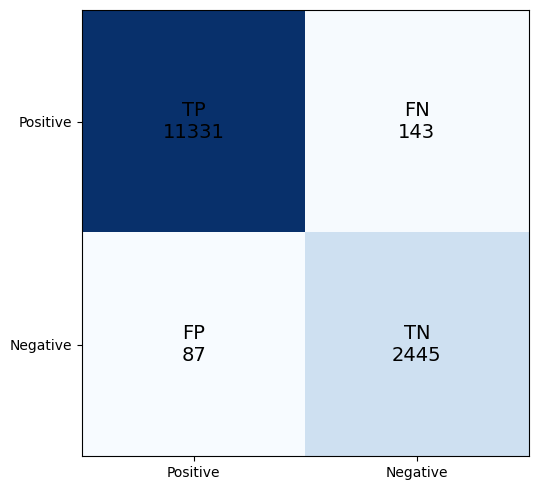

In [117]:
from sklearn import tree
X = train.copy() + train1.copy()
Y = [1] * len(train) + [0] * len(train1)
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, Y)
pred = list(clf.predict(test))
pred1 = list(clf.predict(test1))

tp,tn,fp,fn = 0,0,0,0
for el in pred:
  if el == 1:
    tp += 1
  else:
    fn += 1
for el in pred1:
  if el == 0:
    tn += 1
  else:
    fp += 1
print(tp,tn,tp,fn)
print(f1_score(pred.copy() + pred1.copy(), [1]*len(test) + [0]*len(test1), average = 'macro'))

confusion(tp,tn,fp,fn)

Реализация kNN

11077 2205 11077 397
0.9136666152089471


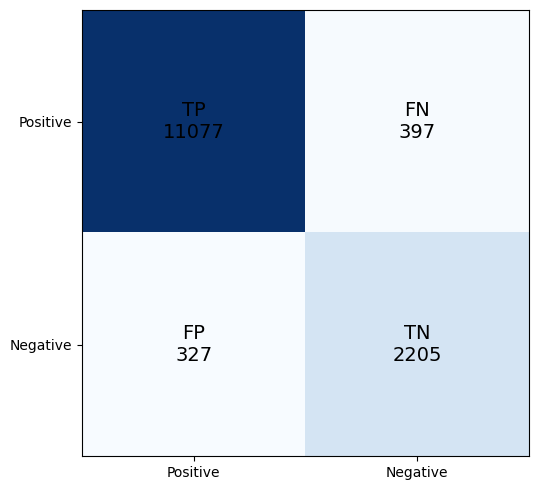

In [119]:
from sklearn.neighbors import KNeighborsClassifier
X = train.copy() + train1.copy()
Y = [1] * len(train) + [0] * len(train1)
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(X, Y)
pred = list(neigh.predict(test))
pred1 = list(neigh.predict(test1))

tp,tn,fp,fn = 0,0,0,0
for el in pred:
  if el == 1:
    tp += 1
  else:
    fn += 1
for el in pred1:
  if el == 0:
    tn += 1
  else:
    fp += 1
print(tp,tn,tp,fn)
print(f1_score(pred.copy() + pred1.copy(), [1]*len(test) + [0]*len(test1), average = 'macro'))

confusion(tp,tn,fp,fn)

Реализация Random Forest

11177 1913 11177 297
0.8837342860669415


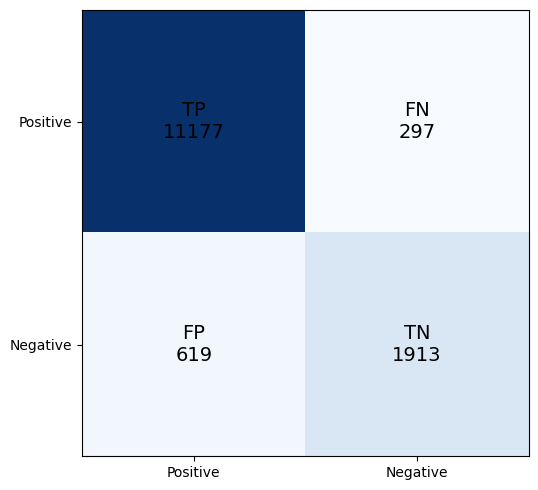

In [120]:
from sklearn.ensemble import RandomForestClassifier
X = train.copy() + train1.copy()
Y = [1] * len(train) + [0] * len(train1)
clf = RandomForestClassifier(max_depth=5, random_state=0)
clf.fit(X, Y)
pred = list(clf.predict(test))
pred1 = list(clf.predict(test1))

tp,tn,fp,fn = 0,0,0,0
for el in pred:
  if el == 1:
    tp += 1
  else:
    fn += 1
for el in pred1:
  if el == 0:
    tn += 1
  else:
    fp += 1
print(tp,tn,tp,fn)
print(f1_score(pred.copy() + pred1.copy(), [1]*len(test) + [0]*len(test1), average = 'macro'))

confusion(tp,tn,fp,fn)

Генерация Confusion Matrix и метрик качества

In [ ]:
def confusion(tp,tn,fp,fn):
  matrix = np.array([[tp, fn], [fp, tn]])
  fig, ax = plt.subplots(figsize=(6, 5))
  im = ax.imshow(matrix, cmap='Blues', interpolation='nearest')
  classes = ['Positive', 'Negative']
  ax.set_xticks(np.arange(len(classes)))
  ax.set_yticks(np.arange(len(classes)))
  ax.set_xticklabels(classes)
  ax.set_yticklabels(classes)

  labels = [["TP", "FN"], ["FP", "TN"]]

  for i in range(2):
      for j in range(2):
          ax.text(j, i, f"{labels[i][j]}\n{matrix[i][j]}",
                  ha="center", va="center",
                  fontsize=14)

  plt.tight_layout()
  plt.show()




def accuracy_score(tp, tn, fp, fn):
    return (tp+tn)/(tp+tn+fp+fn)

def precision_score(tp, tn, fp, fn):
    return tp/(tp+fp)

def recall_score(tp, tn, fp, fn):
    return tp/(tp+fn)

def fpr_score(tp, tn, fp, fn):
    return fp/(fp+tn)